# 02 — Baseline tabular: Q-Learning y ablación de exploración

**Tarea:** Persecución e intercepción de balón (Ball Pursuit). **Algoritmo:** Q-Learning tabular.
**Ablación requerida:** ε constante vs. ε decreciente geométrico.

Este notebook **carga** los resultados guardados por `src/train.py` (Q-tables, historiales, evaluaciones y
configuración completa de cada corrida). Para regenerarlos desde cero, poner `RETRAIN = True`
(≈ 3 min en el contenedor `rl-agent`).

Contrato experimental (ver `src/SPEC.md`):
- mismo presupuesto de episodios y mismas 5 semillas por condición;
- evaluación periódica **greedy** (ε = 0, sin aprendizaje) sobre una lista fija de 500 inicios
  (`sampler.evaluation_starts`, semilla 12345) y el mismo flujo de ruido del simulador
  (números aleatorios comunes), idéntica para todas las condiciones;
- éxito = captura (d ≤ 0.8 m) en < 40 pasos (se reporta también ≤ 40);
- π̂(s) y V̂(s) son **estimaciones aprendidas**, no se afirma que sean óptimas.

In [1]:
import json, os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots
from src.discretizer import Discretizer, DiscretizerConfig
from src.train import ablation_configs, discretization_configs, ExperimentConfig
from src.controllers import GreedyPursuit, rollout
from src.agents import GreedyQPolicy
from src.sim_env import SimBallPursuitEnv
from src.sampler import evaluation_starts
from src.params import load_params

RETRAIN = False
RUNS = "notebooks/artifacts/runs"
RUNS_DISC = "notebooks/artifacts/runs_discretization"
if RETRAIN:
    subprocess.run(["python", "-m", "src.train", "--preset", "discretization", "--out", RUNS_DISC], check=True)
    subprocess.run(["python", "-m", "src.train", "--preset", "discretization", "--alpha", "0.03",
                    "--only", "disc_B_front17.5", "disc_C_front17.5_speed", "--out", RUNS_DISC], check=True)
    subprocess.run(["python", "-m", "src.train", "--preset", "ablation", "--out", RUNS], check=True)
params = load_params("notebooks/artifacts/server_params.json")

## 1. Configuración de las corridas

Valores leídos de los `config.json` guardados junto a cada Q-table.

In [2]:
runs = plots.load_runs(RUNS)
cfg = runs[next(iter(runs))][0]["config"]
disc = Discretizer(DiscretizerConfig(**{k: tuple(v) for k, v in cfg["discretizer"].items()}))
rows = [("algoritmo", cfg["algorithm"]), ("α (tasa de aprendizaje)", cfg["alpha"]), ("γ", cfg["gamma"]),
        ("episodios por corrida", cfg["n_episodes"]), ("semillas", cfg["seeds"]),
        ("T_max (pasos = ciclos del servidor)", cfg["t_max"]),
        ("bordes de distancia [m]", cfg["discretizer"]["distance_edges"]),
        ("bordes de ángulo [°]", cfg["discretizer"]["angle_edges"]),
        ("bordes de velocidad [m/ciclo]", cfg["discretizer"]["speed_edges"]),
        ("|S| (incl. UNKNOWN) × |A|", f"{disc.n_states} × {len(cfg['actions'])} = {disc.n_states * len(cfg['actions'])}"),
        ("acciones", ", ".join(cfg["actions"])),
        ("evaluación", f"{cfg['eval_episodes']} inicios fijos cada {cfg['eval_every']} episodios")]
for name, rs in runs.items():
    rows.append((f"schedule: {name}", rs[0]["config"]["schedule"]))
display(Markdown("| parámetro | valor |\n|---|---|\n" + "\n".join(f"| {a} | {b} |" for a, b in rows)))

| parámetro | valor |
|---|---|
| algoritmo | qlearning |
| α (tasa de aprendizaje) | 0.03 |
| γ | 0.99 |
| episodios por corrida | 20000 |
| semillas | [0, 1, 2, 3, 4] |
| T_max (pasos = ciclos del servidor) | 40 |
| bordes de distancia [m] | [3.0, 10.0, 20.0] |
| bordes de ángulo [°] | [17.5, 90.0, 180.0] |
| bordes de velocidad [m/ciclo] | [0.2] |
| |S| (incl. UNKNOWN) × |A| | 41 × 4 = 164 |
| acciones | DASH 100, DASH 50, TURN +35, TURN -35 |
| evaluación | 500 inicios fijos cada 1000 episodios |
| schedule: qlearning_eps_const_0.1 | {'kind': 'constant', 'eps': 0.1} |
| schedule: qlearning_eps_decay_1.0_to_0.1 | {'kind': 'decay', 'eps_start': 1.0, 'eps_min': 0.1, 'decay': 0.9998081363171082} |

## 2. Selección de la representación de estado

Comparación interna de candidatos de discretización bajo condiciones idénticas (Q-Learning, ε decreciente,
20 000 episodios, 5 semillas). La justificación analítica está en `01_mdp_formulation.ipynb`; aquí la
evidencia empírica. «Últimas 5» = media de las 5 últimas evaluaciones greedy (más robusta que la última
sola); «peor» = la peor de esas evaluaciones en cualquier semilla (mide la inestabilidad de la política).

In [3]:
disc_runs = plots.load_runs(RUNS_DISC)
lines = ["| representación | α | |S| | final <40 | últimas 5 <40 | peor de últimas 5 |", "|---|---|---|---|---|---|"]
for name, rs in disc_runs.items():
    c = rs[0]["config"]
    d = Discretizer(DiscretizerConfig(**{k: tuple(v) for k, v in c["discretizer"].items()}))
    final = [r["final_eval"]["capture_rate_lt40"] for r in rs]
    last5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
    worst = min(min(e["capture_rate_lt40"] for e in r["evals"][-5:]) for r in rs)
    lines.append(f"| {name} | {c['alpha']} | {d.n_states} | {np.mean(final):.3f} ± {np.std(final):.3f} | "
                 f"{np.mean(last5):.3f} ± {np.std(last5):.3f} | {worst:.3f} |")
display(Markdown("\n".join(lines)))

| representación | α | |S| | final <40 | últimas 5 <40 | peor de últimas 5 |
|---|---|---|---|---|---|
| disc_A_front10 | 0.1 | 21 | 0.620 ± 0.061 | 0.574 ± 0.080 | 0.162 |
| disc_B_front17.5 | 0.1 | 21 | 0.736 ± 0.002 | 0.697 ± 0.041 | 0.186 |
| disc_B_front17.5_alpha0.03 | 0.03 | 21 | 0.736 ± 0.002 | 0.732 ± 0.008 | 0.636 |
| disc_C_front17.5_speed | 0.1 | 41 | 0.703 ± 0.068 | 0.714 ± 0.024 | 0.568 |
| disc_C_front17.5_speed_alpha0.03 | 0.03 | 41 | 0.738 ± 0.006 | 0.739 ± 0.007 | 0.708 |
| disc_D_front5_17.5_speed | 0.1 | 57 | 0.604 ± 0.127 | 0.623 ± 0.059 | 0.132 |

Lectura:
- **Frente ±17.5° (B) vs ±10° (A):** con giros de exactamente 35°, en reposo solo se alcanzan rumbos
  separados 35°; el error residual puede llegar a 17.5°. Con un frente de ±10°, muchos rumbos nunca entran al
  bin frontal girando en reposo y la política oscila entre giros. ±17.5° corresponde a la mitad del cuanto de giro.
- **Bit de velocidad (C):** el giro efectivo es 35/(1 + 5v): 35° en reposo y ≈ 12° a velocidad de crucero.
  Sin velocidad en el estado, el mismo bin exige acciones distintas (aliasing); el bit reduce el colapso de la
  política.
- **α = 0.03** estabiliza los valores Q bajo aliasing (con α = 0.1 la política greedy colapsa
  periódicamente). Se adopta **C con α = 0.03** para la ablación.

## 3. Ablación de exploración: ε constante vs. ε decreciente geométrico

Ambas condiciones terminan en el mismo nivel de exploración (ε = 0.1): la decreciente parte de 1.0 y alcanza
0.1 al 60 % del presupuesto (ε_k = max(0.1, 1.0 · λ^k)). Referencias: el controlador heurístico ±35
(`controllers.GreedyPursuit`) evaluado en el simulador con los mismos inicios, y el criterio de éxito de la
tarea (90 %).

controlador heurístico (mismos inicios): captura <40 = 0.716


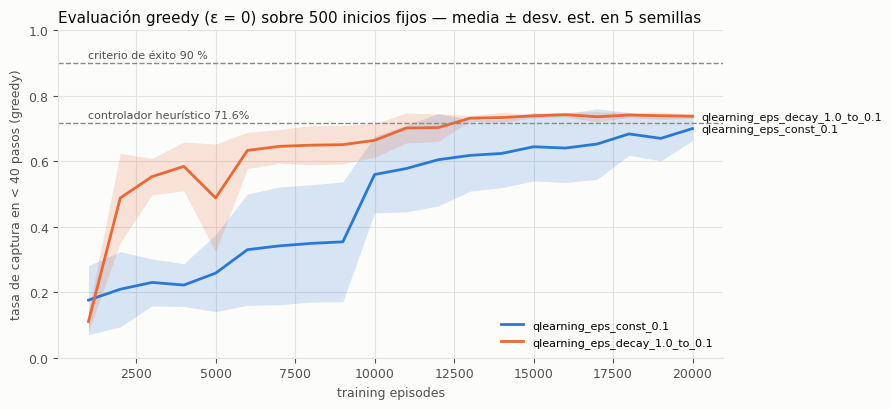

In [4]:
sim_eval = SimBallPursuitEnv(params, seed=cfg["eval_seed"])
starts = evaluation_starts(cfg["eval_episodes"], seed=cfg["eval_seed"])
sim_eval.rng = np.random.default_rng(cfg["eval_seed"])
baseline = [rollout(sim_eval, GreedyPursuit(params), s) for s in starts]
base_rate = np.mean([(b["capture_step"] or 10**6) <= 39 for b in baseline])
print(f"controlador heurístico (mismos inicios): captura <40 = {base_rate:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.2))
plots.plot_eval_curves(runs, "capture_rate_lt40", refs={"criterio de éxito 90 %": 0.9,
                       f"controlador heurístico {base_rate:.1%}": base_rate}, ax=ax,
                       title="Evaluación greedy (ε = 0) sobre 500 inicios fijos — media ± desv. est. en 5 semillas",
                       ylabel="tasa de captura en < 40 pasos (greedy)")
ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_eval_capture.png", dpi=200)

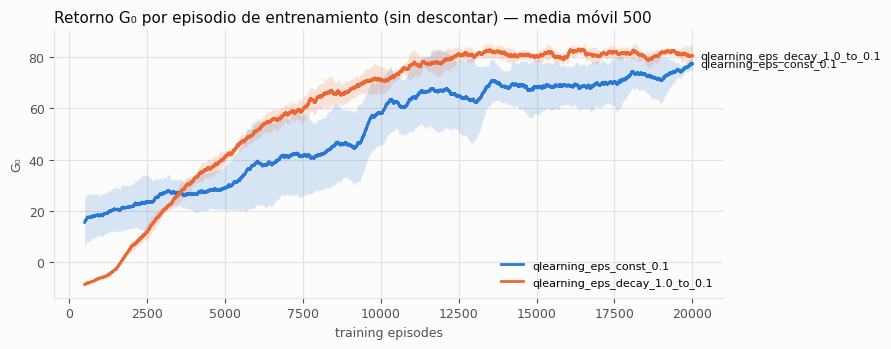

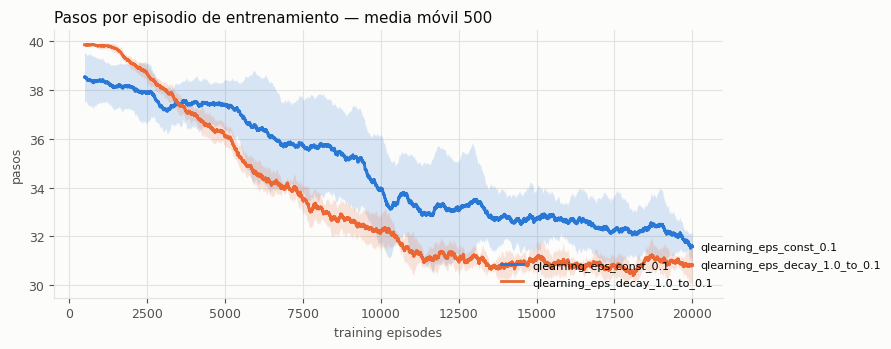

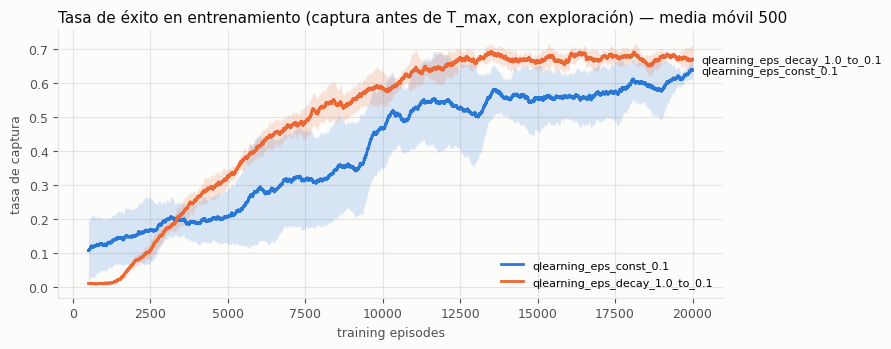

In [5]:
for key, title, ylabel in [
        ("return", "Retorno G₀ por episodio de entrenamiento (sin descontar)", "G₀"),
        ("steps", "Pasos por episodio de entrenamiento", "pasos"),
        ("captured", "Tasa de éxito en entrenamiento (captura antes de T_max, con exploración)", "tasa de captura")]:
    fig, ax = plt.subplots(figsize=(9, 3.6))
    plots.plot_training_curve(runs, key, window=500, ax=ax, title=title + " — media móvil 500", ylabel=ylabel)
    fig.tight_layout(); fig.savefig(f"notebooks/artifacts/fig_train_{key}.png", dpi=200)

In [6]:
lines = ["| condición | final <40 | final ≤40 | últimas 5 <40 | G₀ greedy (final) | pasos greedy (final) | episodios hasta 70 % greedy |",
         "|---|---|---|---|---|---|---|"]
for name, rs in runs.items():
    f = lambda k: [r["final_eval"][k] for r in rs]
    last5 = [np.mean([e["capture_rate_lt40"] for e in r["evals"][-5:]]) for r in rs]
    reach = [next((e["episode"] for e in r["evals"] if e["capture_rate_lt40"] >= 0.70), None) for r in rs]
    reach_s = f"{np.mean([x for x in reach if x]):.0f}" + ("" if all(reach) else f" ({sum(1 for x in reach if not x)} semillas no llegan)")
    lines.append(f"| {name} | {np.mean(f('capture_rate_lt40')):.3f} ± {np.std(f('capture_rate_lt40')):.3f} | "
                 f"{np.mean(f('capture_rate_le40')):.3f} | {np.mean(last5):.3f} ± {np.std(last5):.3f} | "
                 f"{np.mean(f('mean_return')):.1f} | {np.mean(f('mean_steps')):.1f} | {reach_s} |")
display(Markdown("\n".join(lines)))

| condición | final <40 | final ≤40 | últimas 5 <40 | G₀ greedy (final) | pasos greedy (final) | episodios hasta 70 % greedy |
|---|---|---|---|---|---|---|
| qlearning_eps_const_0.1 | 0.700 ± 0.037 | 0.730 | 0.669 ± 0.073 | 88.1 | 30.3 | 11000 (2 semillas no llegan) |
| qlearning_eps_decay_1.0_to_0.1 | 0.738 ± 0.006 | 0.763 | 0.739 ± 0.007 | 91.6 | 29.5 | 9600 |

## 4. Política π̂(s) y valor V̂(s) aprendidos

Se muestra la semilla con mejor evaluación final de la condición con mejor media. Celdas «—»: estados no
visitados durante el entrenamiento. Cada celda lleva el nombre de la acción (el color solo la refuerza).

condición: qlearning_eps_decay_1.0_to_0.1 | semilla: 4 | captura <40: 0.75


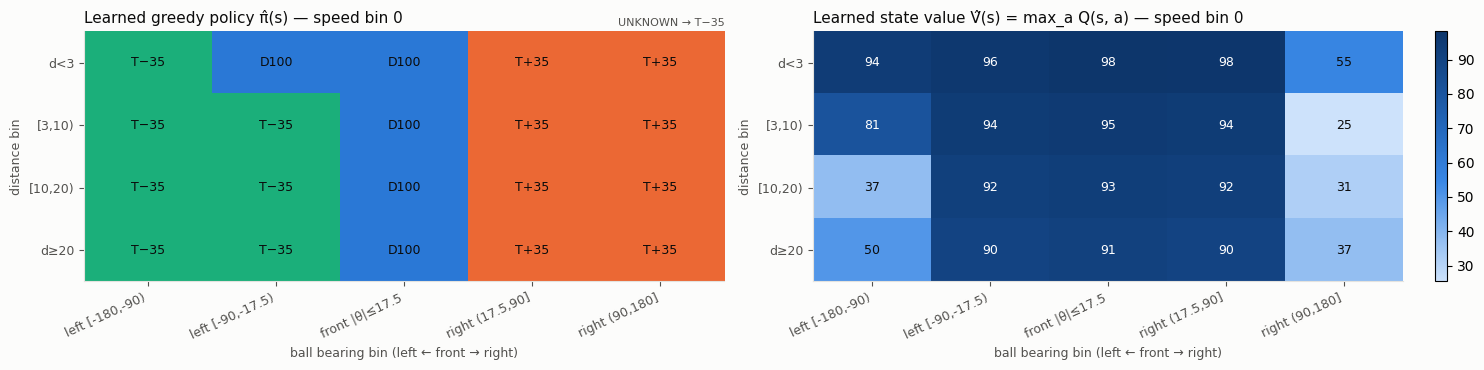

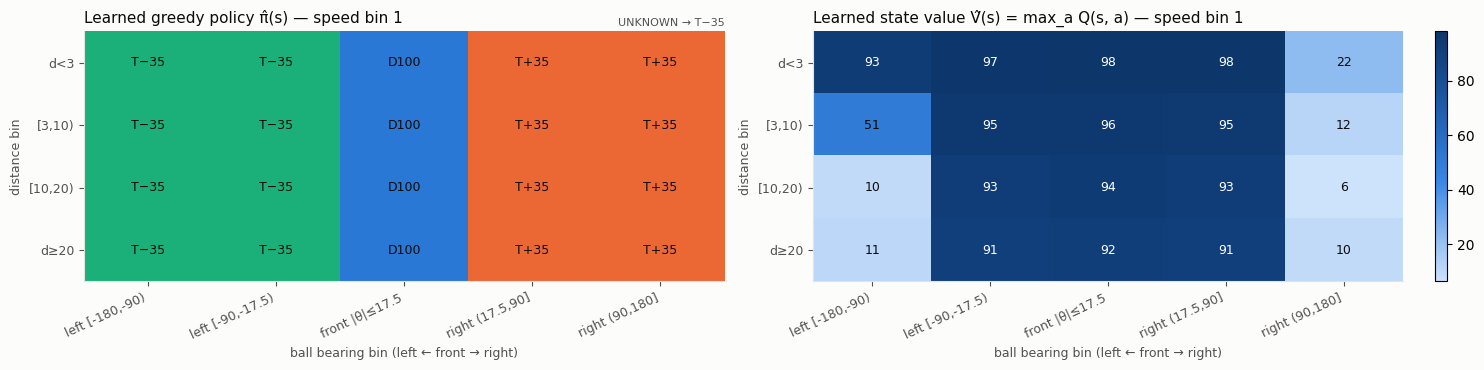

In [7]:
best_cond = max(runs, key=lambda n: np.mean([r["final_eval"]["capture_rate_lt40"] for r in runs[n]]))
best = max(runs[best_cond], key=lambda r: r["final_eval"]["capture_rate_lt40"])
print("condición:", best_cond, "| semilla:", best["seed"], "| captura <40:", best["final_eval"]["capture_rate_lt40"])
Q = best["Q"]
visited = (Q != 0).any(axis=1).astype(int)
for sb in range(disc.n_speed):
    fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
    plots.plot_policy(Q, disc, visits=visited, speed_bin=sb, ax=axes[0])
    plots.plot_value(Q, disc, speed_bin=sb, ax=axes[1])
    fig.tight_layout(); fig.savefig(f"notebooks/artifacts/fig_policy_value_speed{sb}.png", dpi=200)

## 5. Trayectorias 2D en el simulador (política greedy aprendida)

Mismos inicios fijos de evaluación. La trayectoria en el servidor real está en `03_live_validation.ipynb`.

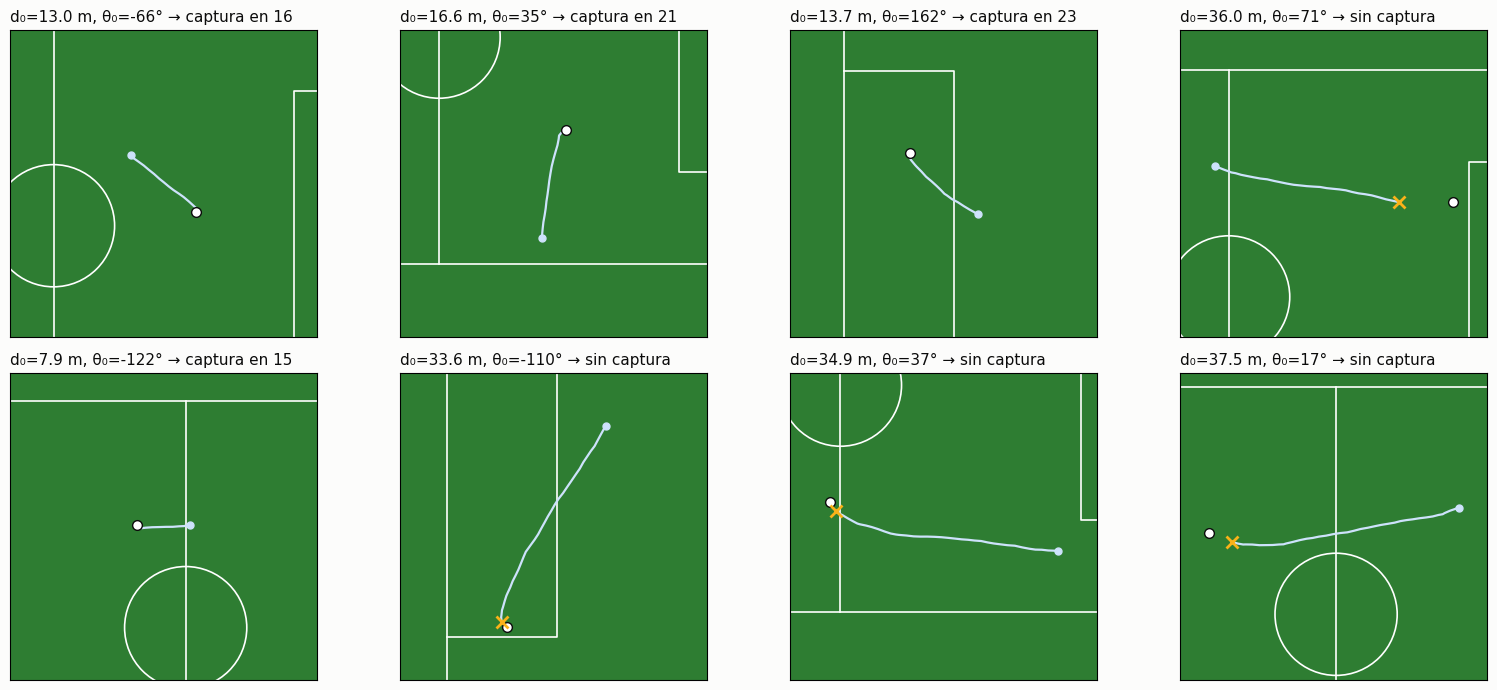

In [8]:
policy = GreedyQPolicy(Q, disc)
sim_eval.rng = np.random.default_rng(cfg["eval_seed"])
recs = [rollout(sim_eval, policy, s) for s in starts[:8]]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for rec, ax in zip(recs, axes.ravel()):
    plots.plot_trajectories([rec], ax=ax, title=f"d₀={rec['start'].distance:.1f} m, θ₀={rec['start'].bearing:.0f}° → "
                            + (f"captura en {rec['steps']}" if rec["captured"] else "sin captura"))
    ax.title.set_fontsize(9)
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_sim_trajectories.png", dpi=200)